In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data =pd.DataFrame({
    "study_hours":[1, 2, 3, 4, 5, 6],
    "attendance":[50,55,65,70,80,90],
    "previous_marks":[40,45,50,55,60,65],
    "final_marks":[45,50,60,65,75,85]
})

correlation_matrix = data.corr(numeric_only=True)
print(correlation_matrix)




                study_hours  attendance  previous_marks  final_marks
study_hours          1.0000      0.9941          1.0000       0.9941
attendance           0.9941      1.0000          0.9941       1.0000
previous_marks       1.0000      0.9941          1.0000       0.9941
final_marks          0.9941      1.0000          0.9941       1.0000


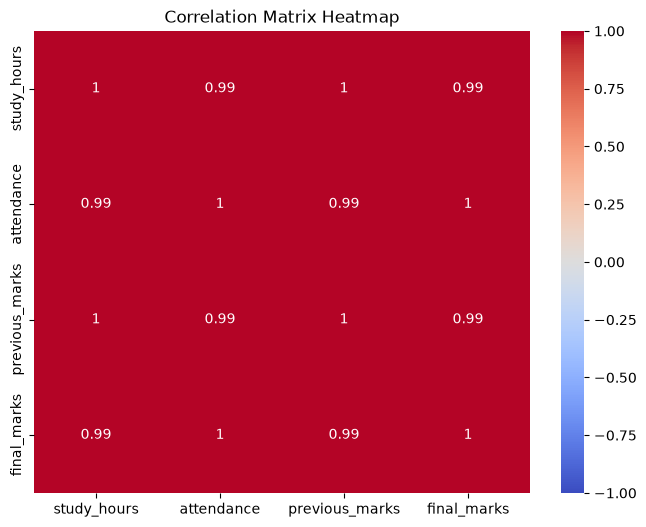

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

Chi-Square Test

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

data = load_breast_cancer()
x=data.data
y=data.target


In [5]:
print("Number of features before feature selection:", x.shape[1])

Number of features before feature selection: 30


In [6]:
x_non_negative = MinMaxScaler().fit_transform(x)

selector = SelectKBest(score_func=chi2, k=5)
x_selected = selector.fit_transform(x_non_negative, y)

selected_features = data.feature_names[selector.get_support()]

print("Selected features:", selected_features)

Selected features: ['mean concavity' 'mean concave points' 'worst perimeter' 'worst area'
 'worst concave points']


In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


In [8]:
iris_data = load_iris()
X,y = iris_data.data, iris_data.target

In [9]:
X_select = SelectKBest(score_func=chi2, k=3).fit_transform(X, y)

X_select

array([[5.1, 1.4, 0.2],
       [4.9, 1.4, 0.2],
       [4.7, 1.3, 0.2],
       [4.6, 1.5, 0.2],
       [5. , 1.4, 0.2],
       [5.4, 1.7, 0.4],
       [4.6, 1.4, 0.3],
       [5. , 1.5, 0.2],
       [4.4, 1.4, 0.2],
       [4.9, 1.5, 0.1],
       [5.4, 1.5, 0.2],
       [4.8, 1.6, 0.2],
       [4.8, 1.4, 0.1],
       [4.3, 1.1, 0.1],
       [5.8, 1.2, 0.2],
       [5.7, 1.5, 0.4],
       [5.4, 1.3, 0.4],
       [5.1, 1.4, 0.3],
       [5.7, 1.7, 0.3],
       [5.1, 1.5, 0.3],
       [5.4, 1.7, 0.2],
       [5.1, 1.5, 0.4],
       [4.6, 1. , 0.2],
       [5.1, 1.7, 0.5],
       [4.8, 1.9, 0.2],
       [5. , 1.6, 0.2],
       [5. , 1.6, 0.4],
       [5.2, 1.5, 0.2],
       [5.2, 1.4, 0.2],
       [4.7, 1.6, 0.2],
       [4.8, 1.6, 0.2],
       [5.4, 1.5, 0.4],
       [5.2, 1.5, 0.1],
       [5.5, 1.4, 0.2],
       [4.9, 1.5, 0.2],
       [5. , 1.2, 0.2],
       [5.5, 1.3, 0.2],
       [4.9, 1.4, 0.1],
       [4.4, 1.3, 0.2],
       [5.1, 1.5, 0.2],
       [5. , 1.3, 0.3],
       [4.5, 1.3

f_classif Applies the ANOVA F-Test to each feature

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, chi2, f_classif

data = load_iris()
X = data.data
y = data.target

selector_f_classif = SelectKBest(score_func=f_classif, k=2)
X_selected_f_classif = selector_f_classif.fit_transform(X, y)

import numpy as np

selected_features_f_classif = np.array(data.feature_names)[selector_f_classif.get_support()]
print("Selected features using f_classif:", selected_features_f_classif)

Selected features using f_classif: ['petal length (cm)' 'petal width (cm)']


For Regression Scikit Learn provides f_regression